In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (update the path if necessary)
df = pd.read_csv('/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Inspect dimensions and columns
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14

In [4]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

/tmp/ipykernel_1949/2504962243.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1949/2504962243.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WorkLifeBalance', y='Attrition', data=df, ax=axes[4], errorbar=None, palette='plasma')
/tmp/ipykernel_1949/2504962243.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='DistanceFromHome', data=df, ax=axes[5], palette='Set3')


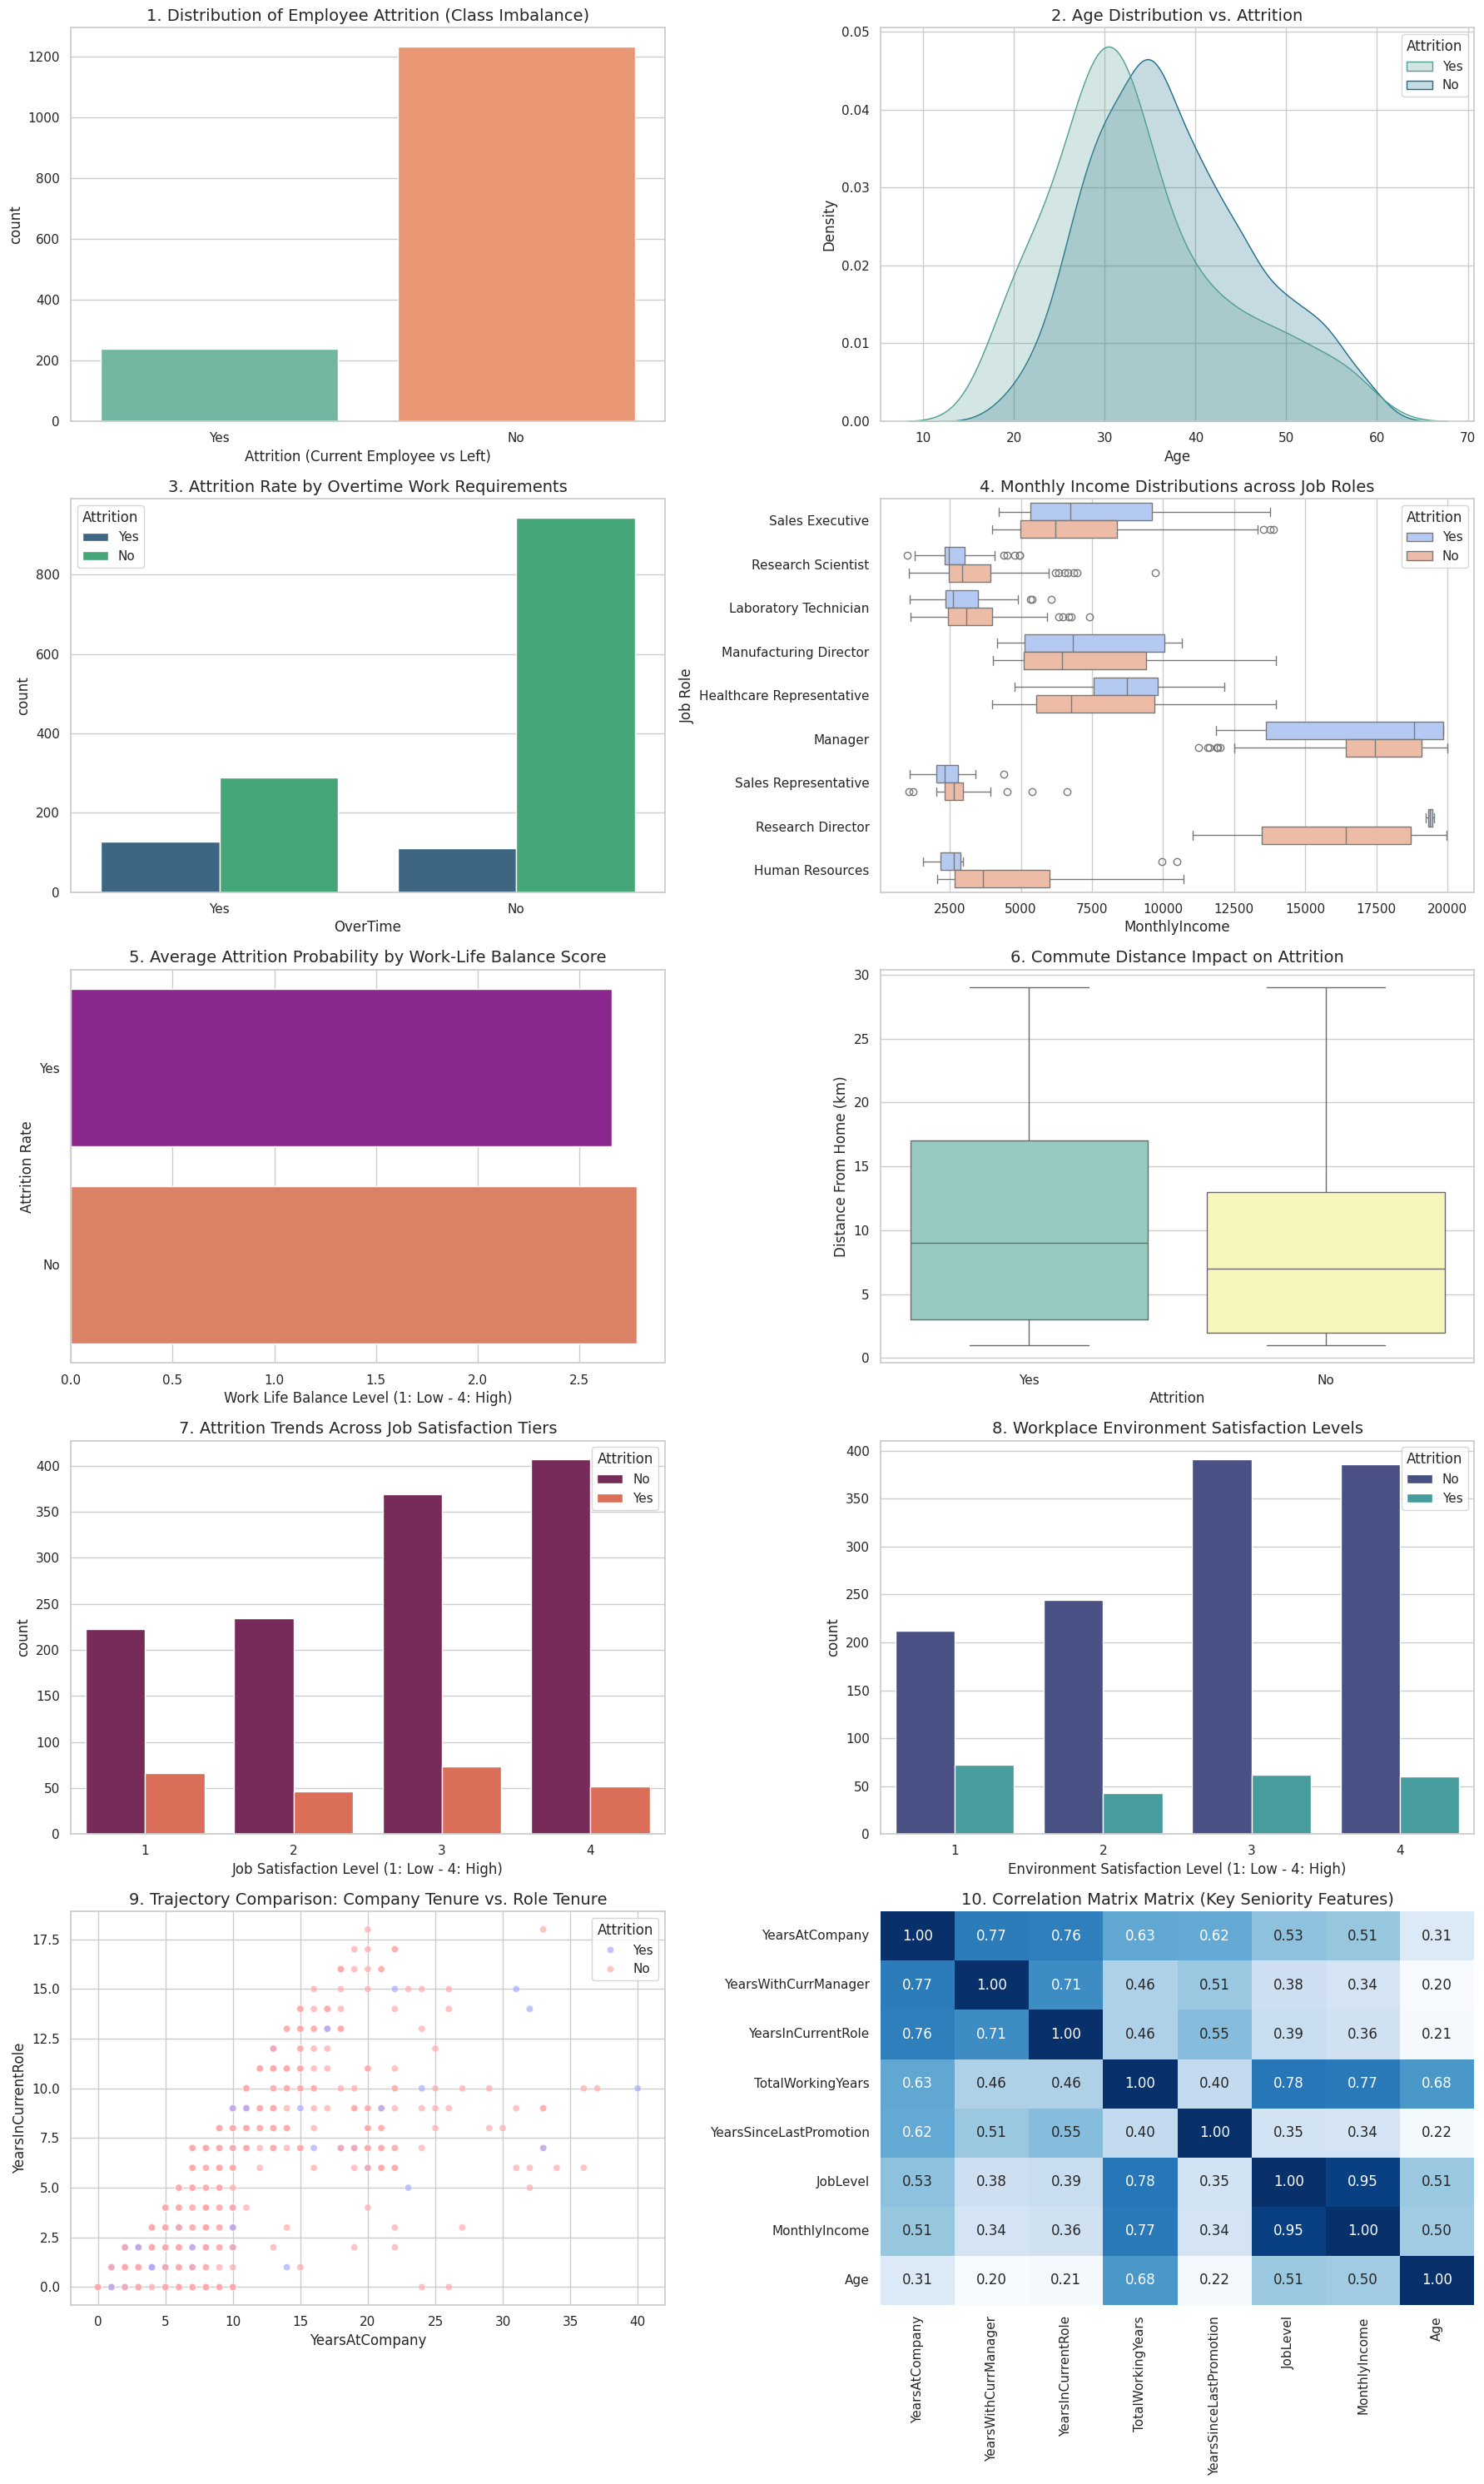


--- Phase 2 Complete: Operational Baseline Statistics ---
Total Active Employees Analysed: 1233
Total Exited Employees Analysed: 237
Base Line Attrition Imbalance Ratio: 16.12%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ---------------------------------------------------------
# 1. DATA LOADING & CLEANING
# ---------------------------------------------------------

# Load the dataset (Make sure the file name matches your downloaded CSV)
df = pd.read_csv('/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop columns with zero variance or irrelevant unique IDs immediately
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Handle missing values & duplicates programmatically (Ethical Baseline)
df.drop_duplicates(inplace=True)
# Fill numerical missing values with median, categorical with mode (if any exist)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# ---------------------------------------------------------
# 2. GENERATING THE 10 REQUIRED VISUALIZATIONS
# ---------------------------------------------------------

# Create a large grid canvas for 10 subplots (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 30))
axes = axes.flatten() # Flatten grid matrix into a 1D array for easy indexing

# Chart 1: Target Class Distribution (Imbalance Check)
sns.countplot(x='Attrition', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('1. Distribution of Employee Attrition (Class Imbalance)')
axes[0].set_xlabel('Attrition (Current Employee vs Left)')

# Chart 2: Age Distribution by Attrition
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, common_norm=False, ax=axes[1], palette='crest')
axes[1].set_title('2. Age Distribution vs. Attrition')

# Chart 3: OverTime Impact
sns.countplot(x='OverTime', hue='Attrition', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('3. Attrition Rate by Overtime Work Requirements')

# Chart 4: Monthly Income Breakdown by Job Role & Attrition
sns.boxplot(x='MonthlyIncome', y='JobRole', hue='Attrition', data=df, ax=axes[3], palette='coolwarm')
axes[3].set_title('4. Monthly Income Distributions across Job Roles')
axes[3].set_ylabel('Job Role')

# Chart 5: Work-Life Balance Ratings
sns.barplot(x='WorkLifeBalance', y='Attrition', data=df, ax=axes[4], errorbar=None, palette='plasma')
axes[4].set_title('5. Average Attrition Probability by Work-Life Balance Score')
axes[4].set_xlabel('Work Life Balance Level (1: Low - 4: High)')
axes[4].set_ylabel('Attrition Rate')

# Chart 6: Distance From Home Impact
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df, ax=axes[5], palette='Set3')
axes[5].set_title('6. Commute Distance Impact on Attrition')
axes[5].set_ylabel('Distance From Home (km)')

# Chart 7: Job Satisfaction Ratings
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, ax=axes[6], palette='rocket')
axes[6].set_title('7. Attrition Trends Across Job Satisfaction Tiers')
axes[6].set_xlabel('Job Satisfaction Level (1: Low - 4: High)')

# Chart 8: Environment Satisfaction Ratings
sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=df, ax=axes[7], palette='mako')
axes[7].set_title('8. Workplace Environment Satisfaction Levels')
axes[7].set_xlabel('Environment Satisfaction Level (1: Low - 4: High)')

# Chart 9: Tenure - Years At Company vs Years In Current Role
sns.scatterplot(x='YearsAtCompany', y='YearsInCurrentRole', hue='Attrition', data=df, ax=axes[8], alpha=0.7, palette='bwr')
axes[8].set_title('9. Trajectory Comparison: Company Tenure vs. Role Tenure')

# Chart 10: Statistical Feature Correlation Heatmap (Numerical Columns Only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
# Take a slice of the matrix or select key metrics to keep heatmap clean
top_features = corr_matrix['YearsAtCompany'].sort_values(ascending=False).index[:8]
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap='Blues', ax=axes[9], cbar=False)
axes[9].set_title('10. Correlation Matrix Matrix (Key Seniority Features)')

# Optimize spacing layout so titles do not overlap
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. EXTRACTION OF SUMMARY INSIGHTS
# ---------------------------------------------------------
print("\n--- Phase 2 Complete: Operational Baseline Statistics ---")
print(f"Total Active Employees Analysed: {df[df['Attrition']=='No'].shape[0]}")
print(f"Total Exited Employees Analysed: {df[df['Attrition']=='Yes'].shape[0]}")
print(f"Base Line Attrition Imbalance Ratio: {round((df[df['Attrition']=='Yes'].shape[0] / df.shape[0]) * 100, 2)}%")

In [10]:
# ---------------------------------------------------------
# PHASE 3: DATA PREPROCESSING & ETHICAL SPLITTING
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Encode the Binary Target Variable
# Converting 'Yes' to 1 and 'No' to 0
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# 3. One-Hot Encode Categorical Features
# This handles variables like BusinessTravel, Department, JobRole, and MaritalStatus
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Ethical Train-Test Split (80% Training, 20% Testing)
# We use 'stratify=y' to preserve the exact imbalance ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Feature Scaling
# Machine learning models perform best when numerical features are on the same scale
scaler = StandardScaler()

# Fit only on the training set to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Apply SMOTE to Address Class Imbalance
# CRITICAL ETHICAL STEP: We apply SMOTE *only* to the training partition.
# The test set must remain completely untouched to reflect a realistic distribution.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ---------------------------------------------------------
# VERIFICATION REPORT
# ---------------------------------------------------------
print("--- Phase 3 Complete: Pipeline Data Dimensions ---")
print(f"Original Training Set Attrition Split: Stayed = {sum(y_train==0)}, Left = {sum(y_train==1)}")
print(f"Resampled (SMOTE) Training Set Attrition Split: Stayed = {sum(y_train_resampled==0)}, Left = {sum(y_train_resampled==1)}")
print(f"Untouched Testing Set Size: {X_test_scaled.shape[0]} samples (Attrition Rate: {round(sum(y_test==1)/len(y_test)*100, 2)}%)")

--- Phase 3 Complete: Pipeline Data Dimensions ---
Original Training Set Attrition Split: Stayed = 986, Left = 190
Resampled (SMOTE) Training Set Attrition Split: Stayed = 986, Left = 986
Untouched Testing Set Size: 294 samples (Attrition Rate: 15.99%)


In [11]:
# ---------------------------------------------------------
# PHASE 4: MODEL BUILDING & EVALUATION PIPELINE
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. Initialize All Required Classification Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# 2. Train and Evaluate Models Sequentially
performance_records = []

for name, model in models.items():
    # Fit model on the balanced SMOTE training data
    model.fit(X_train_resampled, y_train_resampled)

    # Generate predictions on the real-world scaled test data
    predictions = model.predict(X_test_scaled)
    prediction_probabilities = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate performance metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, prediction_probabilities)

    # Store performance metrics
    performance_records.append({
        "Model Name": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall (Sensitivity)": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

# 3. Render the Professional Model Comparison Table
df_performance = pd.DataFrame(performance_records)
print("--- Phase 4 Complete: Model Comparison Table ---")
print(df_performance.to_string(index=False))

# 4. Print Confusion Matrix for the Best Performing Model (Example: XGBoost / Random Forest)
# (This helps meet your requirement for structural validation and report depth)
print("\n--- Structural Check: Confusion Matrix (XGBoost Example) ---")
xgb_cm = confusion_matrix(y_test, models["XGBoost"].predict(X_test_scaled))
print(f"True Negatives (Predicted Stay, Actually Stayed): {xgb_cm[0][0]}")
print(f"False Positives (Predicted Leave, Actually Stayed): {xgb_cm[0][1]}")
print(f"False Negatives (Predicted Stay, Actually Left): {xgb_cm[1][0]}")
print(f"True Positives (Predicted Leave, Actually Left): {xgb_cm[1][1]}")

--- Phase 4 Complete: Model Comparison Table ---
            Model Name  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC
   Logistic Regression    0.7755     0.3733                0.5957    0.4590   0.7854
         Random Forest    0.8299     0.4348                0.2128    0.2857   0.7833
Support Vector Machine    0.8197     0.4211                0.3404    0.3765   0.7185
               XGBoost    0.8741     0.6923                0.3830    0.4932   0.7963

--- Structural Check: Confusion Matrix (XGBoost Example) ---
True Negatives (Predicted Stay, Actually Stayed): 239
False Positives (Predicted Leave, Actually Stayed): 8
False Negatives (Predicted Stay, Actually Left): 29
True Positives (Predicted Leave, Actually Left): 18


In [12]:
df.to_csv('Pandit_Parth_Sharma_Cleaned_Attrition_Data.csv', index=False)